In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import statsmodels.api as sm
from google.colab import files
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [13]:
uploaded = files.upload()

Saving 2025-food-environment-atlas-data.xlsx to 2025-food-environment-atlas-data (1).xlsx


In [14]:
file_name = '2025-food-environment-atlas-data.xlsx'

# 1. Load specific sheets
stores_raw = pd.read_excel(file_name, sheet_name='STORES', header=1)
restaurants_raw = pd.read_excel(file_name, sheet_name='RESTAURANTS', header=1)
socio_raw = pd.read_excel(file_name, sheet_name='SOCIOECONOMIC', header=1)
health_raw = pd.read_excel(file_name, sheet_name='HEALTH', header=1)

# 2. Select ALL potentially relevant variables from each sheet upfront
# Keep FIPS, State, County for identification and merging

# Stores Data: All available columns for potential use
stores_cols = ['FIPS', 'State', 'County', 'GROCPTH16', 'CONVSPTH16', 'GROCPTH20', 'SUPERC20', 'CONVS20', 'SNAPS23', 'WICS22']
df_stores = stores_raw[stores_cols]

# Restaurants Data: All available columns for potential use
restaurants_cols = ['FIPS', 'FFRPTH16', 'FFR20', 'FSR20']
df_restaurants = restaurants_raw[restaurants_cols]

# Socioeconomic Data: All available columns for potential use
socio_cols = ['FIPS', 'MEDHHINC21', 'POVRATE21', 'PCT_NHWHITE20', 'PCT_NHBLACK20', 'PCT_HISP20',
              'PCT_NHASIAN20', 'PCT_NHNA20', 'PCT_NHPI20', 'PCT_NHOR20', 'PCT_NHTMR20',
              'PCT_65OLDER20', 'PCT_18YOUNGER20', 'DEEPPOVRATE21', 'PERPOV17_21', 'CHILDPOVRATE21']
df_socio = socio_raw[socio_cols]

# Health Data: All available columns for potential use
health_cols = ['FIPS', 'PCT_OBESE_ADULTS17', 'RECFACPTH20', 'PCT_DIABETES_ADULTS19']
df_health = health_raw[health_cols]

# 3. Merge all selected features into a master analysis dataframe
df_master = df_stores.merge(df_restaurants, on='FIPS', how='left') \
                     .merge(df_socio, on='FIPS', how='left') \
                     .merge(df_health, on='FIPS', how='left')

# Clean data: Replace -9999 and -8888 (USDA null flags) with NaN, then remove rows with any NaN values
df_master = df_master.replace([-9999, -8888], np.nan).dropna()

print(f"Initial master dataset ready with {len(df_master)} U.S. Counties and {len(df_master.columns)} features.")
display(df_master.head())

Initial master dataset ready with 649 U.S. Counties and 31 features.


,FIPS,State,County,GROCPTH16,CONVSPTH16,GROCPTH20,SUPERC20,CONVS20,SNAPS23,WICS22,...,PCT_NHOR20,PCT_NHTMR20,PCT_65OLDER20,PCT_18YOUNGER20,DEEPPOVRATE21,PERPOV17_21,CHILDPOVRATE21,PCT_OBESE_ADULTS17,RECFACPTH20,PCT_DIABETES_ADULTS19
1,1003,AL,Baldwin,0.139566,0.567889,0.126479,9.0,118.0,215.0,27.0,...,0.334388,4.473458,21.871103,21.269637,4.043401,0.0,16.4,36.3,0.095950,7.9
7,1015,AL,Calhoun,0.234709,0.730206,0.185073,5.0,78.0,142.0,18.0,...,0.272241,3.923017,18.401594,20.741835,8.329656,0.0,25.2,36.3,0.052878,13.3
25,1051,AL,Elmore,0.098452,0.676856,0.109545,3.0,56.0,81.0,10.0,...,0.312582,3.723701,16.673676,21.564727,4.048460,0.0,17.3,36.3,0.060858,14.2
34,1069,AL,Houston,0.162905,0.680370,0.159505,4.0,73.0,136.0,21.0,...,0.330218,3.958881,18.898901,22.906289,7.770839,0.0,27.1,36.3,0.103209,13.2
36,1073,AL,Jefferson,0.161997,0.694921,0.172429,18.0,464.0,541.0,74.0,...,0.291380,2.812125,16.779973,21.880748,7.317956,0.0,23.6,36.3,0.141911,11.8


In [15]:
# Create a copy for feature engineering
df_fe = df_master.copy()

# 1. Calculate the Food Swamp Ratio (RFEI)
# This measures the ratio of fast-food and convenience stores to grocery stores.
# Add a small constant to the denominator to avoid division by zero.
df_fe['swamp_ratio'] = (df_fe['FFRPTH16'] + df_fe['CONVSPTH16']) / (df_fe['GROCPTH16'] + 0.001)

# 2. Additional Interaction and Ratio Features
# Ratio of grocery stores to convenience stores
df_fe['GROC_CONV_RATIO'] = df_fe['GROCPTH16'] / (df_fe['CONVSPTH16'] + 0.001)

# Ratio of fast-food restaurants to grocery stores
df_fe['FF_GROC_RATIO'] = df_fe['FFRPTH16'] / (df_fe['GROCPTH16'] + 0.001)

# Income and Poverty Interaction
df_fe['INCOME_POVERTY_INTERACTION'] = df_fe['MEDHHINC21'] * df_fe['POVRATE21']

# Swamp Ratio and Income Interaction
df_fe['SWAMP_INCOME_INTERACTION'] = df_fe['swamp_ratio'] * df_fe['MEDHHINC21']

# Swamp Ratio and Poverty Rate Interaction
df_fe['SWAMP_POVERTY_INTERACTION'] = df_fe['swamp_ratio'] * df_fe['POVRATE21']

# Income to Poverty Ratio
df_fe['INCOME_POVERTY_RATIO'] = df_fe['MEDHHINC21'] / (df_fe['POVRATE21'] + 0.001)

# Diabetes and Swamp Ratio Interaction
df_fe['DIABETES_SWAMP_INTERACTION'] = df_fe['PCT_DIABETES_ADULTS19'] * df_fe['swamp_ratio']

# Diabetes and Poverty Interaction
df_fe['DIABETES_POVERTY_INTERACTION'] = df_fe['PCT_DIABETES_ADULTS19'] * df_fe['POVRATE21']

# Fast-food Ratio and Diabetes Interaction
df_fe['FF_DIABETES_INTERACTION'] = df_fe['FF_GROC_RATIO'] * df_fe['PCT_DIABETES_ADULTS19']

print("DataFrame with all engineered features:")
display(df_fe.head())

DataFrame with all engineered features:


,FIPS,State,County,GROCPTH16,CONVSPTH16,GROCPTH20,SUPERC20,CONVS20,SNAPS23,WICS22,...,swamp_ratio,GROC_CONV_RATIO,FF_GROC_RATIO,INCOME_POVERTY_INTERACTION,SWAMP_INCOME_INTERACTION,SWAMP_POVERTY_INTERACTION,INCOME_POVERTY_RATIO,DIABETES_SWAMP_INTERACTION,DIABETES_POVERTY_INTERACTION,FF_DIABETES_INTERACTION
1,1003,AL,Baldwin,0.139566,0.567889,0.126479,9.0,118.0,215.0,27.0,...,9.381060,0.245331,5.341041,709106.4,615941.606558,101.315443,6078.881585,74.110370,85.32,42.194227
7,1015,AL,Calhoun,0.234709,0.730206,0.185073,5.0,78.0,142.0,18.0,...,6.601503,0.320989,3.503591,924787.2,317968.014768,126.748866,2508.515182,87.799996,255.36,46.597763
25,1051,AL,Elmore,0.098452,0.676856,0.109545,3.0,56.0,81.0,10.0,...,11.631853,0.145240,4.825981,757764.0,734516.599239,139.582232,5261.811516,165.172308,170.40,68.528935
34,1069,AL,Houston,0.162905,0.680370,0.159505,4.0,73.0,136.0,21.0,...,10.932888,0.239085,6.781899,930189.1,532442.590008,208.818165,2549.657086,144.314125,252.12,89.521061
36,1073,AL,Jefferson,0.161997,0.694921,0.172429,18.0,464.0,541.0,74.0,...,10.848918,0.232780,6.585517,933049.0,598968.783791,183.346721,3266.670611,128.017237,199.42,77.709095


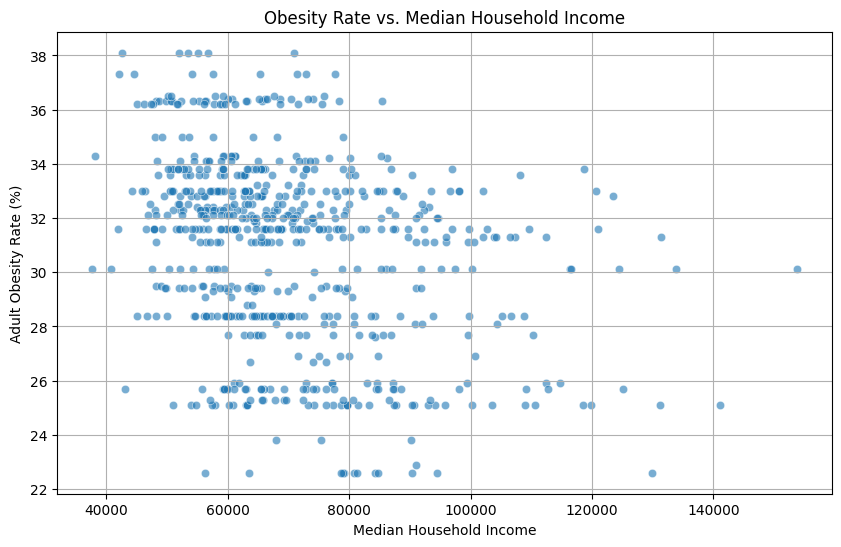

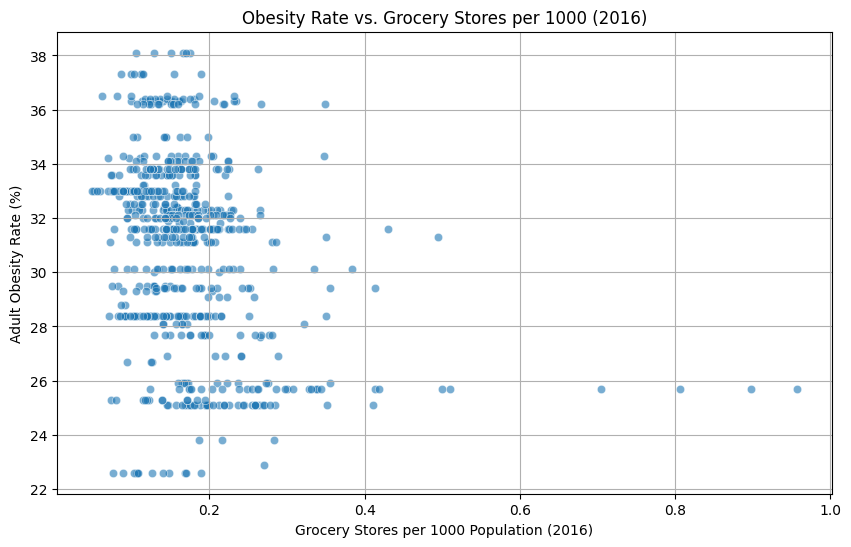

/tmp/ipykernel_15447/243202894.py:61: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



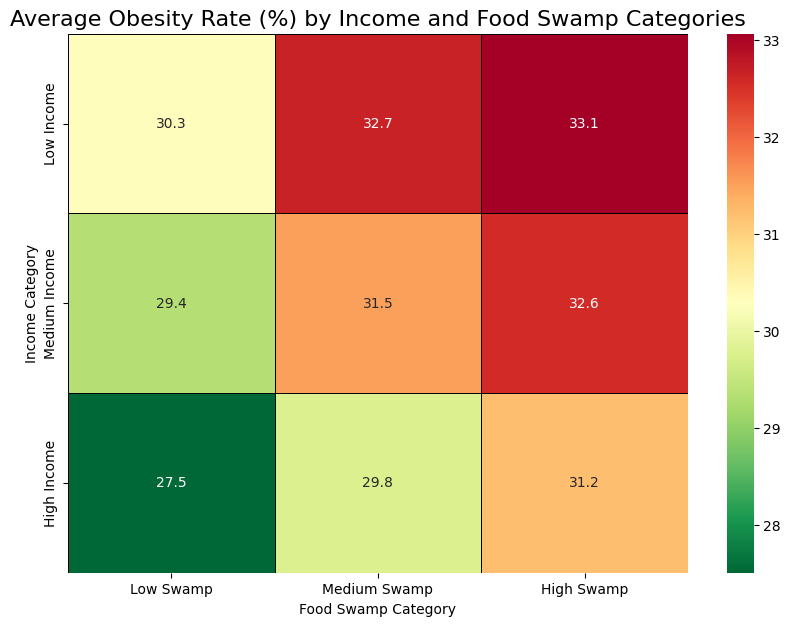

TOP 10 HIGH-LEVERAGE COUNTIES FOR NUTRITION INTERVENTION:
     State      County  swamp_ratio  PCT_OBESE_ADULTS17  MEDHHINC21
2192    OK       Payne    21.448569                36.5     50651.0
2629    TX        Hays    20.774984                33.0     79336.0
1463    MS      Rankin    18.019946                37.3     71478.0
1440    MS  Lauderdale    16.960699                37.3     44492.0
2759    TX    Victoria    18.752408                33.0     57142.0
2689    TX     Midland    18.441874                33.0     84837.0
2570    TX       Comal    17.579644                33.0     93487.0
2745    TX      Taylor    17.056228                33.0     53820.0
2676    TX     Lubbock    16.186653                33.0     57270.0
739     IN     Johnson    15.872131                33.6     79914.0


In [16]:
# Top 10 counties by Obesity Rate
top_obesity = df_fe.sort_values(by='PCT_OBESE_ADULTS17', ascending=False).head(10)

fig_obesity = px.bar(
    top_obesity,
    x='County',
    y='PCT_OBESE_ADULTS17',
    color='PCT_OBESE_ADULTS17',
    title='Top 10 Counties by Adult Obesity Rate',
    hover_data=['State', 'MEDHHINC21', 'GROCPTH16', 'CONVSPTH16'],
    labels={'PCT_OBESE_ADULTS17': 'Obesity Rate (%)'},
    color_continuous_scale=px.colors.sequential.Plasma
)
fig_obesity.update_layout(xaxis_title='County', yaxis_title='Obesity Rate (%)')
fig_obesity.show()

# Top 10 counties by Food Swamp Ratio
top_swamp = df_fe.sort_values(by='swamp_ratio', ascending=False).head(10)

# Create a combined 'County, State' column for better labeling
top_swamp['County_State'] = top_swamp['County'] + ', ' + top_swamp['State']

fig_swamp = px.bar(
    top_swamp,
    x='County_State',
    y='swamp_ratio',
    color='swamp_ratio',
    title='Top 10 Counties by Food Swamp Ratio',
    hover_data=['State', 'PCT_OBESE_ADULTS17', 'GROCPTH16', 'CONVSPTH16', 'FFRPTH16'],
    labels={'swamp_ratio': 'Food Swamp Ratio', 'County_State': 'County, State'},
    color_continuous_scale=px.colors.sequential.Viridis
)
fig_swamp.update_layout(xaxis_title='County, State', yaxis_title='Food Swamp Ratio')
fig_swamp.show()

# Relationship between Median Household Income and Obesity Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_fe, x='MEDHHINC21', y='PCT_OBESE_ADULTS17', alpha=0.6)
plt.title('Obesity Rate vs. Median Household Income')
plt.xlabel('Median Household Income')
plt.ylabel('Adult Obesity Rate (%)')
plt.grid(True)
plt.show()

# Relationship between Grocery Stores per 1000 population and Obesity Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_fe, x='GROCPTH16', y='PCT_OBESE_ADULTS17', alpha=0.6)
plt.title('Obesity Rate vs. Grocery Stores per 1000 (2016)')
plt.xlabel('Grocery Stores per 1000 Population (2016)')
plt.ylabel('Adult Obesity Rate (%)')
plt.grid(True)
plt.show()

# Create categorical bins for Median Household Income
df_fe['Income_Category'] = pd.qcut(df_fe['MEDHHINC21'], q=3, labels=['Low Income', 'Medium Income', 'High Income'])

# Create categorical bins for Food Swamp Ratio
df_fe['Swamp_Category'] = pd.qcut(df_fe['swamp_ratio'], q=3, labels=['Low Swamp', 'Medium Swamp', 'High Swamp'])

# Calculate the mean obesity rate for each combination of categories
heatmap_data = df_fe.groupby(['Income_Category', 'Swamp_Category'])['PCT_OBESE_ADULTS17'].mean().unstack()


plt.figure(figsize=(10, 7))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='RdYlGn_r', linewidths=.5, linecolor='black')
plt.title('Average Obesity Rate (%) by Income and Food Swamp Categories', fontsize=16)
plt.xlabel('Food Swamp Category')
plt.ylabel('Income Category')
plt.show()

#'Crisis Score' (Normalized Swamp Ratio * Normalized Obesity)
df_fe['crisis_score'] = (df_fe['swamp_ratio'] / df_fe['swamp_ratio'].max()) * (df_fe['PCT_OBESE_ADULTS17'] / df_fe['PCT_OBESE_ADULTS17'].max())

top_crisis = df_fe.sort_values(by='crisis_score', ascending=False).head(10)

print("TOP 10 HIGH-LEVERAGE COUNTIES FOR NUTRITION INTERVENTION:")
print(top_crisis[['State', 'County', 'swamp_ratio', 'PCT_OBESE_ADULTS17', 'MEDHHINC21']])

# Bar Chart of Top 10 Crisis Score Counties
fig_crisis = px.bar(top_crisis, x='County', y='crisis_score', color='PCT_OBESE_ADULTS17',
             title="Highest Priority 'Food Swamp' Counties by Crisis Score",
             hover_data=['State', 'MEDHHINC21', 'swamp_ratio', 'PCT_OBESE_ADULTS17'],
             labels={'crisis_score':'Crisis Score', 'PCT_OBESE_ADULTS17':'Obesity %'},
             color_continuous_scale=px.colors.sequential.Plasma)
fig_crisis.show()

### High-Swamp, High-Obesity Hotspots: State-Level Analysis

In [17]:
# Aggregate the top_swamp counties by state to see state-level trends
top_swamp_state_agg = top_swamp.groupby('State')['swamp_ratio'].mean().reset_index()
top_swamp_state_agg = top_swamp_state_agg.sort_values(by='swamp_ratio', ascending=False)

fig_swamp_state = px.bar(
    top_swamp_state_agg,
    x='State',
    y='swamp_ratio',
    color='swamp_ratio',
    text_auto=True, # Added to display values on top of bars
    title='Average Food Swamp Ratio by State (from Top 10 Counties)',
    labels={'swamp_ratio': 'Average Food Swamp Ratio'},
    color_continuous_scale=px.colors.sequential.Viridis
)
fig_swamp_state.update_layout(xaxis_title='State', yaxis_title='Average Food Swamp Ratio')
fig_swamp_state.show()

In [18]:
state_hotspots = df_fe.groupby('State')[['swamp_ratio', 'PCT_OBESE_ADULTS17']].mean().reset_index()

# Sort by both swamp_ratio and obesity rate to find combined hotspots
state_hotspots['combined_score'] = state_hotspots['swamp_ratio'] * state_hotspots['PCT_OBESE_ADULTS17']
state_hotspots_sorted = state_hotspots.sort_values(by='combined_score', ascending=False).head(10)

print("TOP 10 STATE-LEVEL HIGH-SWAMP, HIGH-OBESITY HOTSPOTS (by combined score):")
display(state_hotspots_sorted[['State', 'swamp_ratio', 'PCT_OBESE_ADULTS17']])

fig_state_hotspots = px.bar(state_hotspots_sorted,
                            x='State',
                            y='combined_score',
                            color='PCT_OBESE_ADULTS17',
                            title="Top State-Level High-Swamp, High-Obesity Hotspots",
                            hover_data=['swamp_ratio', 'PCT_OBESE_ADULTS17'],
                            labels={'combined_score':'Combined Hotspot Score', 'PCT_OBESE_ADULTS17':'Average Obesity %'},
                            color_continuous_scale=px.colors.sequential.Plasma)
fig_state_hotspots.show()

TOP 10 STATE-LEVEL HIGH-SWAMP, HIGH-OBESITY HOTSPOTS (by combined score):


,State,swamp_ratio,PCT_OBESE_ADULTS17
25,MS,13.189348,37.3
42,TX,12.084169,33.0
35,OK,10.701881,36.5
1,AL,9.790675,36.3
49,WY,11.568257,28.8
48,WV,8.667352,38.1
18,LA,8.374364,36.2
15,IN,8.963152,33.6
12,IA,8.180838,36.4
31,NM,10.466599,28.4


#### Visualizing Key Age and Race Relationships with Obesity

Correlation of Age and Race Factors with PCT_OBESE_ADULTS17:


,PCT_OBESE_ADULTS17
PCT_NHBLACK20,0.30
PCT_18YOUNGER20,0.19
PCT_NHWHITE20,0.13
PCT_NHNA20,-0.04
PCT_65OLDER20,-0.12
PCT_NHTMR20,-0.13
PCT_NHPI20,-0.17
PCT_HISP20,-0.29
PCT_NHASIAN20,-0.32
PCT_NHOR20,-0.38


/tmp/ipykernel_15447/239693909.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




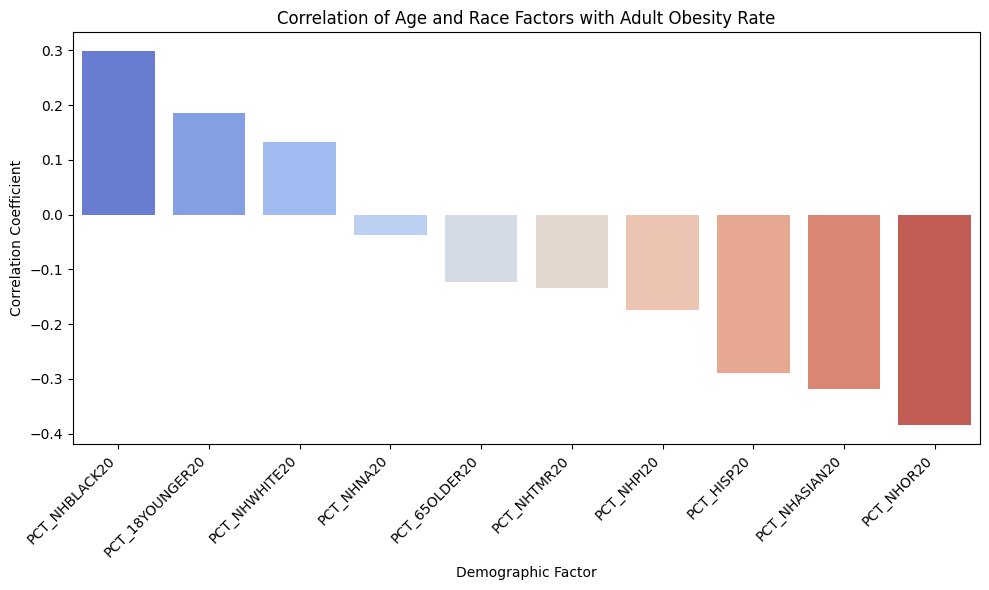

In [19]:
age_race_cols = [
    'PCT_NHWHITE20', 'PCT_NHBLACK20', 'PCT_HISP20', 'PCT_NHASIAN20',
    'PCT_NHNA20', 'PCT_NHPI20', 'PCT_NHOR20', 'PCT_NHTMR20',
    'PCT_65OLDER20', 'PCT_18YOUNGER20',
    'PCT_OBESE_ADULTS17'
]

# Calculate correlation for age and race factors with obesity rate
age_race_corr = df_fe[age_race_cols].corr()['PCT_OBESE_ADULTS17'].drop('PCT_OBESE_ADULTS17').sort_values(ascending=False)

print("Correlation of Age and Race Factors with PCT_OBESE_ADULTS17:")
display(age_race_corr.round(2))

plt.figure(figsize=(10, 6))
sns.barplot(x=age_race_corr.index, y=age_race_corr.values, palette='coolwarm')
plt.title('Correlation of Age and Race Factors with Adult Obesity Rate')
plt.xlabel('Demographic Factor')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

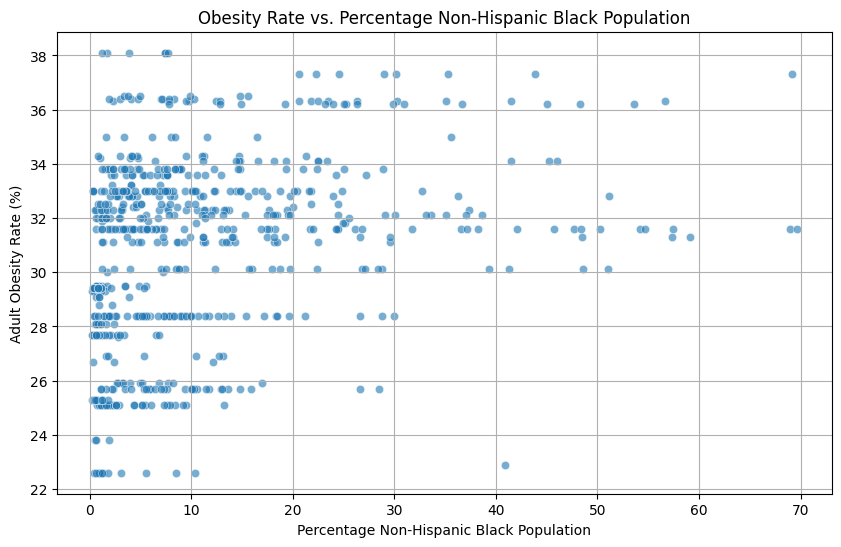

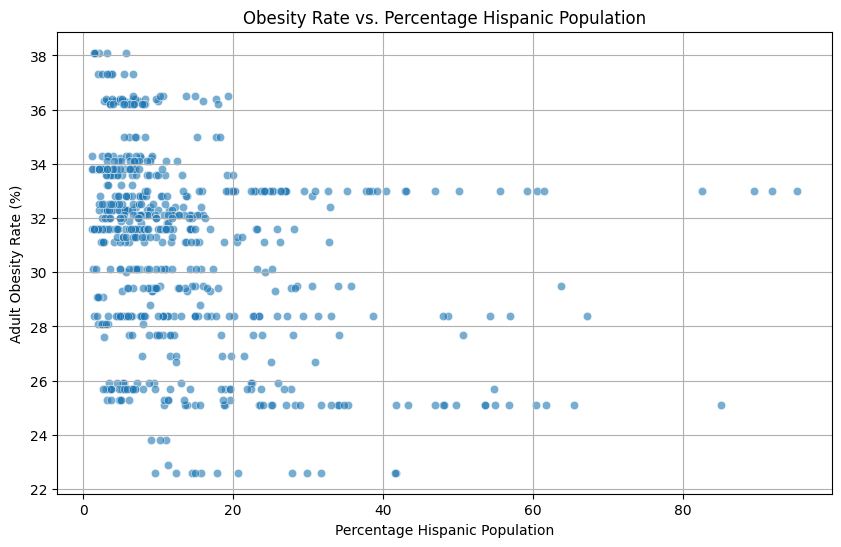

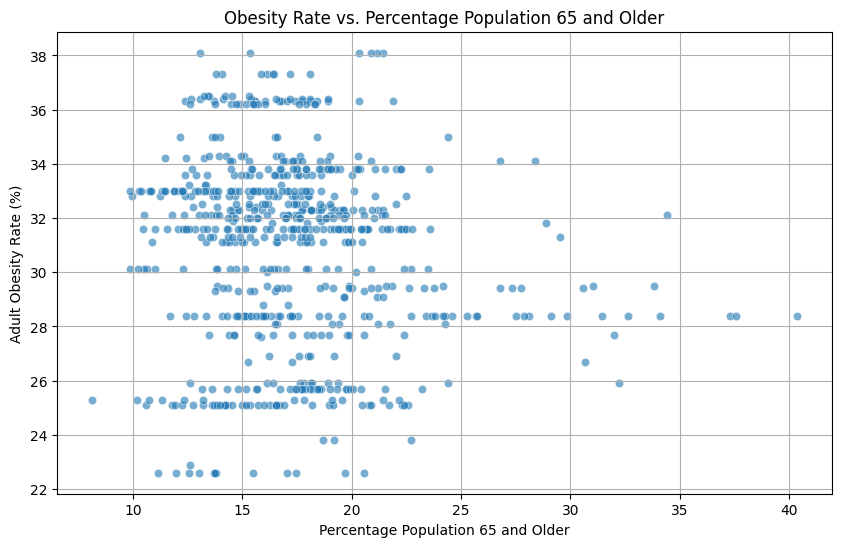

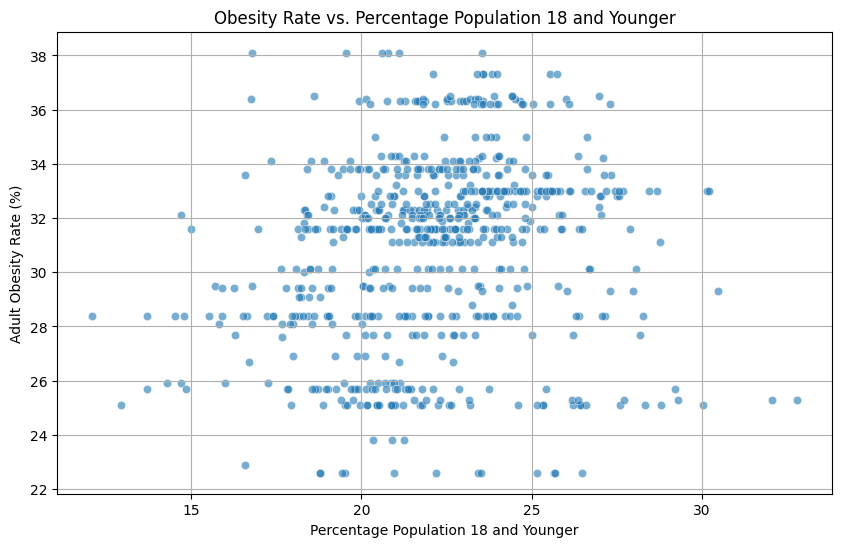

In [20]:
# Scatter plot for PCT_NHBLACK20 vs PCT_OBESE_ADULTS17
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_fe, x='PCT_NHBLACK20', y='PCT_OBESE_ADULTS17', alpha=0.6)
plt.title('Obesity Rate vs. Percentage Non-Hispanic Black Population')
plt.xlabel('Percentage Non-Hispanic Black Population')
plt.ylabel('Adult Obesity Rate (%)')
plt.grid(True)
plt.show()

# Scatter plot for PCT_HISP20 vs PCT_OBESE_ADULTS17
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_fe, x='PCT_HISP20', y='PCT_OBESE_ADULTS17', alpha=0.6)
plt.title('Obesity Rate vs. Percentage Hispanic Population')
plt.xlabel('Percentage Hispanic Population')
plt.ylabel('Adult Obesity Rate (%)')
plt.grid(True)
plt.show()

# Scatter plot for PCT_65OLDER20 vs PCT_OBESE_ADULTS17
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_fe, x='PCT_65OLDER20', y='PCT_OBESE_ADULTS17', alpha=0.6)
plt.title('Obesity Rate vs. Percentage Population 65 and Older')
plt.xlabel('Percentage Population 65 and Older')
plt.ylabel('Adult Obesity Rate (%)')
plt.grid(True)
plt.show()

# Scatter plot for PCT_18YOUNGER20 vs PCT_OBESE_ADULTS17
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_fe, x='PCT_18YOUNGER20', y='PCT_OBESE_ADULTS17', alpha=0.6)
plt.title('Obesity Rate vs. Percentage Population 18 and Younger')
plt.xlabel('Percentage Population 18 and Younger')
plt.ylabel('Adult Obesity Rate (%)')
plt.grid(True)
plt.show()

### Feature Selection based on Correlation

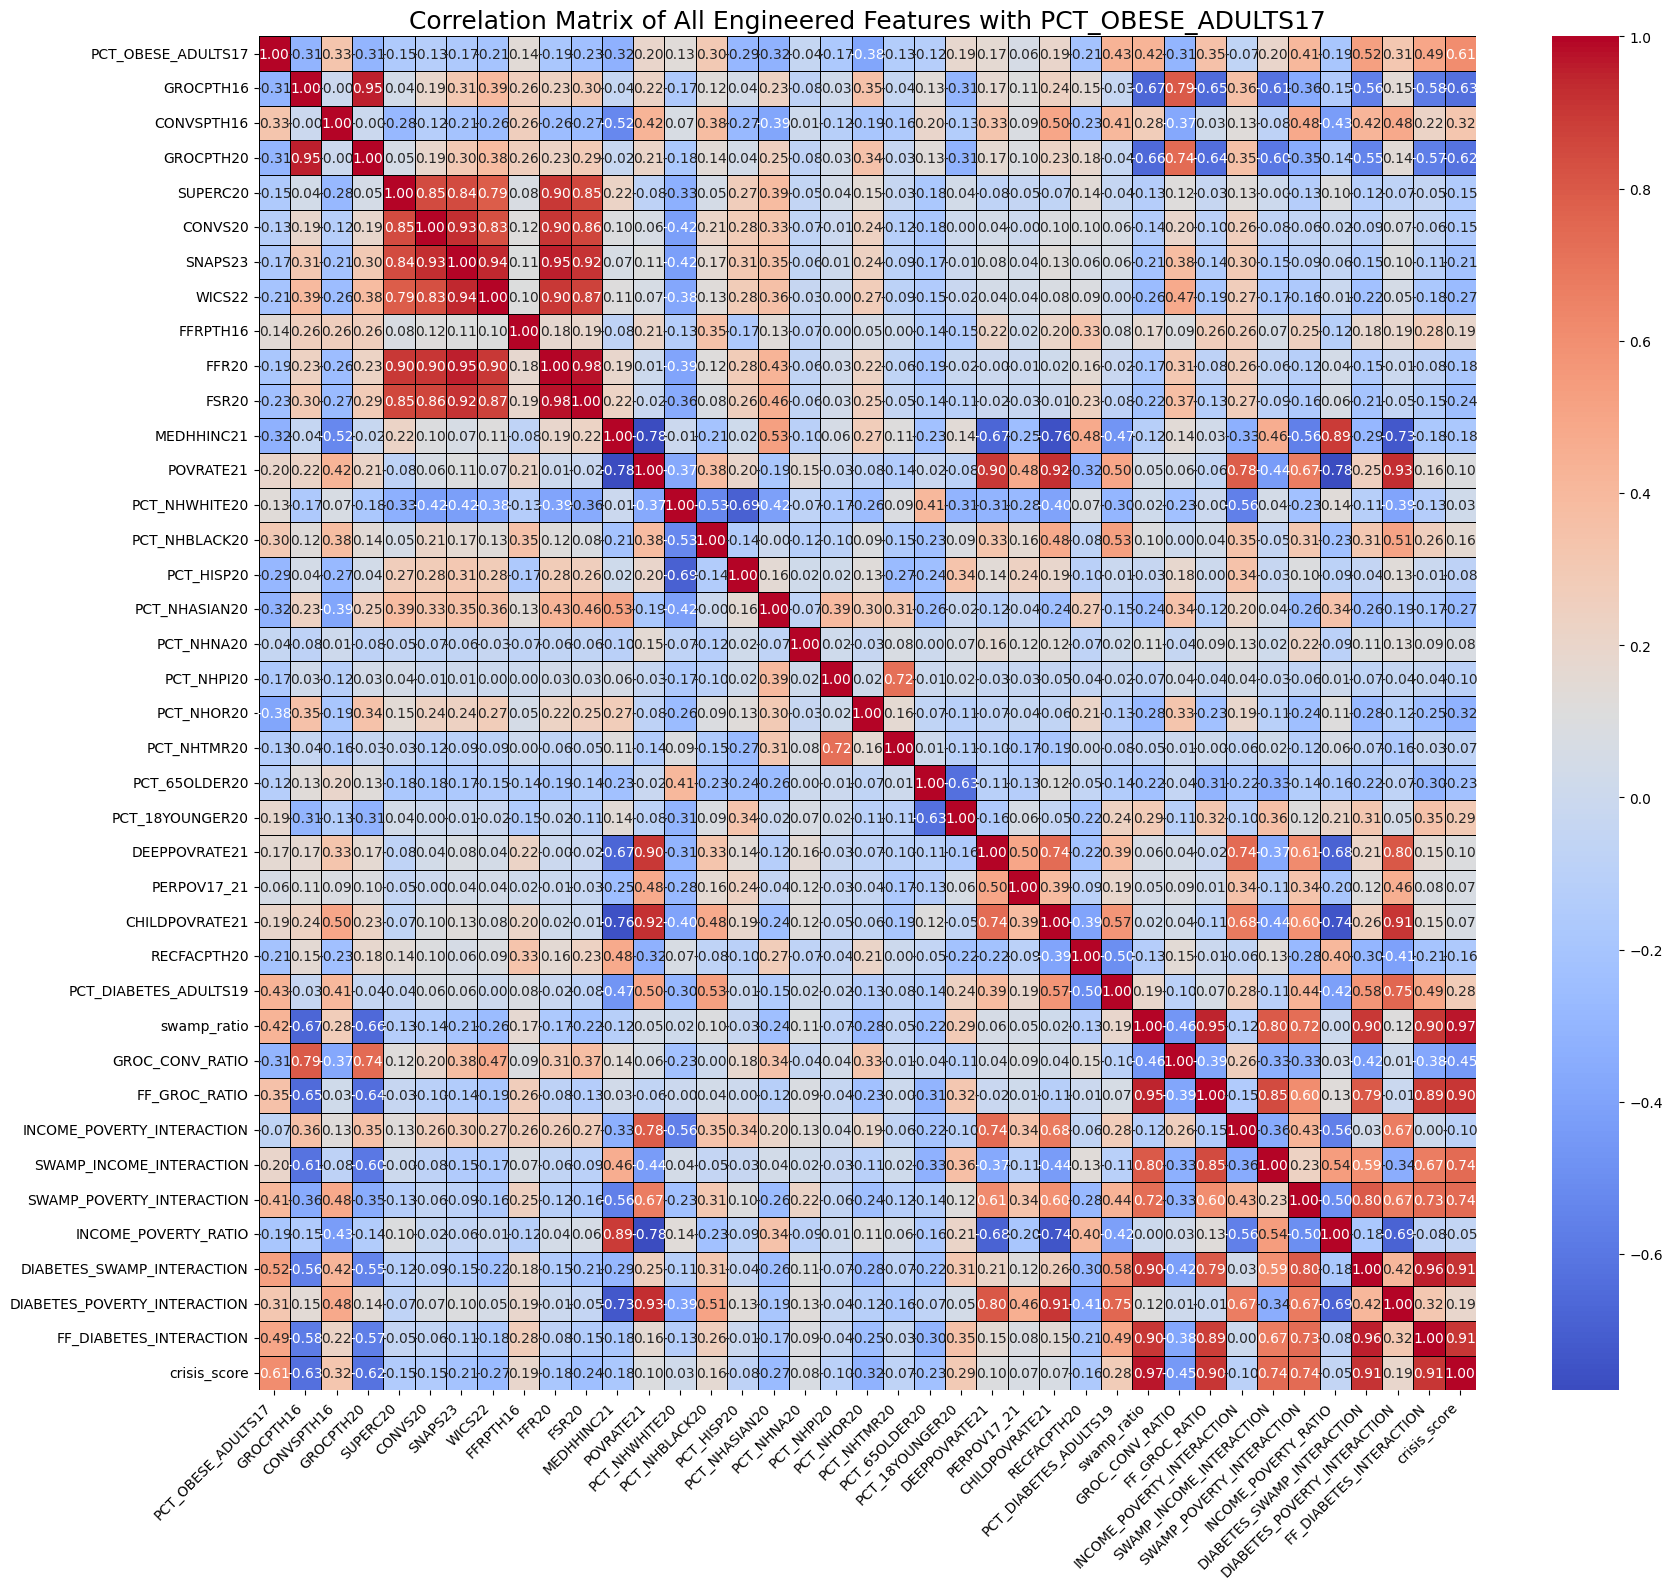

Number of selected features (correlation > 0.3): 15
Selected features based on correlation with PCT_OBESE_ADULTS17:
['crisis_score', 'DIABETES_SWAMP_INTERACTION', 'FF_DIABETES_INTERACTION', 'PCT_DIABETES_ADULTS19', 'swamp_ratio', 'SWAMP_POVERTY_INTERACTION', 'PCT_NHOR20', 'FF_GROC_RATIO', 'CONVSPTH16', 'MEDHHINC21', 'PCT_NHASIAN20', 'DIABETES_POVERTY_INTERACTION', 'GROCPTH16', 'GROCPTH20', 'GROC_CONV_RATIO']

Shape of X (selected features): (649, 15)
Shape of y: (649,)


In [21]:
# Selected numerical columns for correlation analysis, including the target variable
# Exclude FIPS, State, County as they are identifiers

# Filtered for numerical columns and the target variable, excluding categorical columns created for visualization
correlation_cols = df_fe.select_dtypes(include=np.number).columns.tolist()

# Removing FIPS as it's an identifier, not a feature for correlation with target
if 'FIPS' in correlation_cols:
    correlation_cols.remove('FIPS')

# Ensuring target variable is included and in a good position for visualization
if 'PCT_OBESE_ADULTS17' in correlation_cols:
    correlation_cols.remove('PCT_OBESE_ADULTS17')
    correlation_cols = ['PCT_OBESE_ADULTS17'] + correlation_cols

# Calculating the correlation matrix
corr_matrix = df_fe[correlation_cols].corr()

plt.figure(figsize=(18, 16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title('Correlation Matrix of All Engineered Features with PCT_OBESE_ADULTS17', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Get correlations with the target variable, excluding the target itself
correlation_with_target = corr_matrix['PCT_OBESE_ADULTS17'].drop('PCT_OBESE_ADULTS17').abs().sort_values(ascending=False)

correlation_threshold = 0.3

# Selecting features that have a correlation above the threshold
selected_features_list = correlation_with_target[correlation_with_target > correlation_threshold].index.tolist()

print(f"Number of selected features (correlation > {correlation_threshold}): {len(selected_features_list)}")
print("Selected features based on correlation with PCT_OBESE_ADULTS17:")
print(selected_features_list)

# Define features (X) and target (y) with these selected features
X = df_fe[selected_features_list]
y = df_fe['PCT_OBESE_ADULTS17']

# Handle potential NaN values (though df_fe was already dropped NaN)
X = X.fillna(X.mean())
y = y.fillna(y.mean())

print(f"\nShape of X (selected features): {X.shape}")
print(f"Shape of y: {y.shape}")

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (519, 15)
X_test shape: (130, 15)
y_train shape: (519,)
y_test shape: (130,)


In [23]:
# Define the parameter distributions for XGBoost
param_dist_xgb = {
    'n_estimators': randint(100, 300),  # Number of boosting rounds
    'learning_rate': uniform(loc=0.01, scale=0.15),  # Step size shrinkage
    'max_depth': randint(3, 10),  # Maximum depth of a tree
    'min_child_weight': randint(1, 10), # Minimum sum of instance weight (hessian) needed in a child
    'subsample': uniform(loc=0.6, scale=0.4), # Subsample ratio of the training instance
    'colsample_bytree': uniform(loc=0.6, scale=0.4) # Subsample ratio of columns when constructing each tree
}

# Initialize the XGBoost Regressor
xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1)

# Initialize RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_dist_xgb,
                                    n_iter=50, cv=5, n_jobs=-1, verbose=2, scoring='r2', random_state=42) # Increased n_iter and cv for better search

print("Starting RandomizedSearchCV for XGBoost with selected engineered features...")
random_search_xgb.fit(X_train, y_train)
print("RandomizedSearchCV for XGBoost completed.")

# Get the best parameters and best score
best_params_xgb = random_search_xgb.best_params_
best_score_xgb = random_search_xgb.best_score_

print(f"\nBest parameters for XGBoost: {best_params_xgb}")
print(f"Best R-squared score on training data (cross-validation): {best_score_xgb:.2f}")

# Evaluate the best model on the test set
best_xgb_model = random_search_xgb.best_estimator_
y_pred_best_xgb = best_xgb_model.predict(X_test)

mse_best_xgb = mean_squared_error(y_test, y_pred_best_xgb)
rmse_best_xgb = np.sqrt(mse_best_xgb)
mae_best_xgb = mean_absolute_error(y_test, y_pred_best_xgb)
r2_best_xgb = r2_score(y_test, y_pred_best_xgb)

print("\nBest XGBoost Model Test Set Metrics (after tuning):")
print(f"Mean Squared Error (MSE): {mse_best_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_best_xgb:.2f}")
print(f"Mean Absolute Error (MAE): {mae_best_xgb:.2f}")
print(f"R-squared (R2): {r2_best_xgb:.2f}")

# Store metrics for comparison
model_metrics_final = {'XGBoost (Tuned, Selected FE)': {'MSE': mse_best_xgb, 'RMSE': rmse_best_xgb, 'MAE': mae_best_xgb, 'R2': r2_best_xgb}}


Starting RandomizedSearchCV for XGBoost with selected engineered features...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
RandomizedSearchCV for XGBoost completed.

Best parameters for XGBoost: {'colsample_bytree': np.float64(0.9521871356061031), 'learning_rate': np.float64(0.10365310722006899), 'max_depth': 8, 'min_child_weight': 9, 'n_estimators': 233, 'subsample': np.float64(0.782613828193164)}
Best R-squared score on training data (cross-validation): 0.86

Best XGBoost Model Test Set Metrics (after tuning):
Mean Squared Error (MSE): 1.34
Root Mean Squared Error (RMSE): 1.16
Mean Absolute Error (MAE): 0.81
R-squared (R2): 0.89


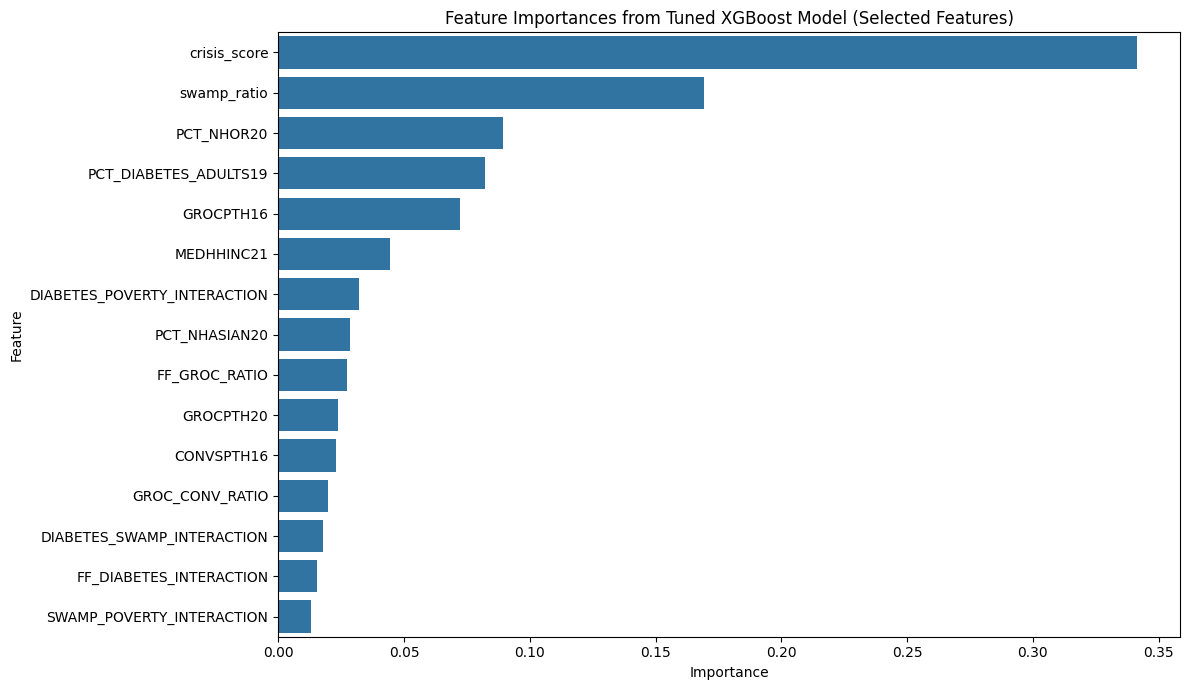

In [24]:
feature_importances_xgb = pd.DataFrame({'feature': X_train.columns, 'importance': best_xgb_model.feature_importances_})
feature_importances_xgb = feature_importances_xgb.sort_values('importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=feature_importances_xgb)
plt.title('Feature Importances from Tuned XGBoost Model (Selected Features)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

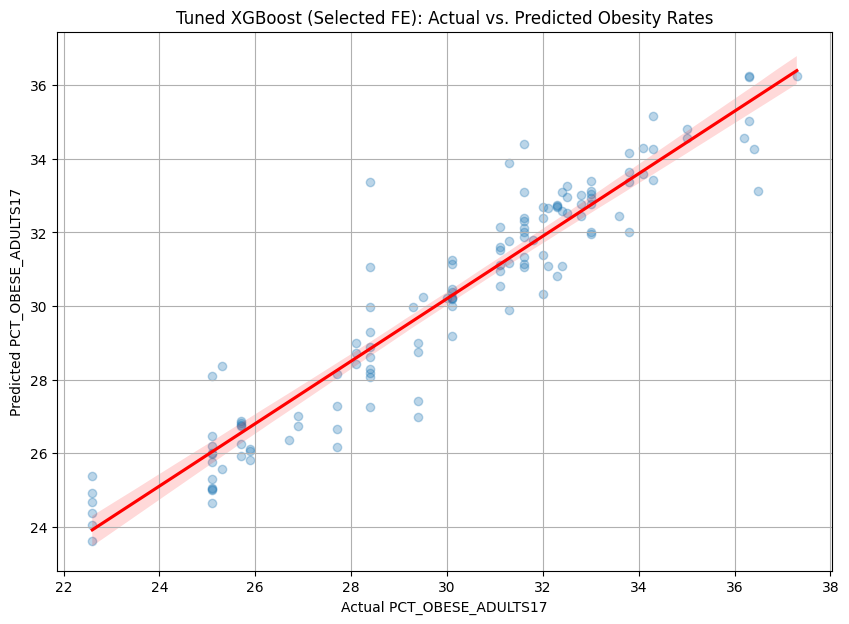

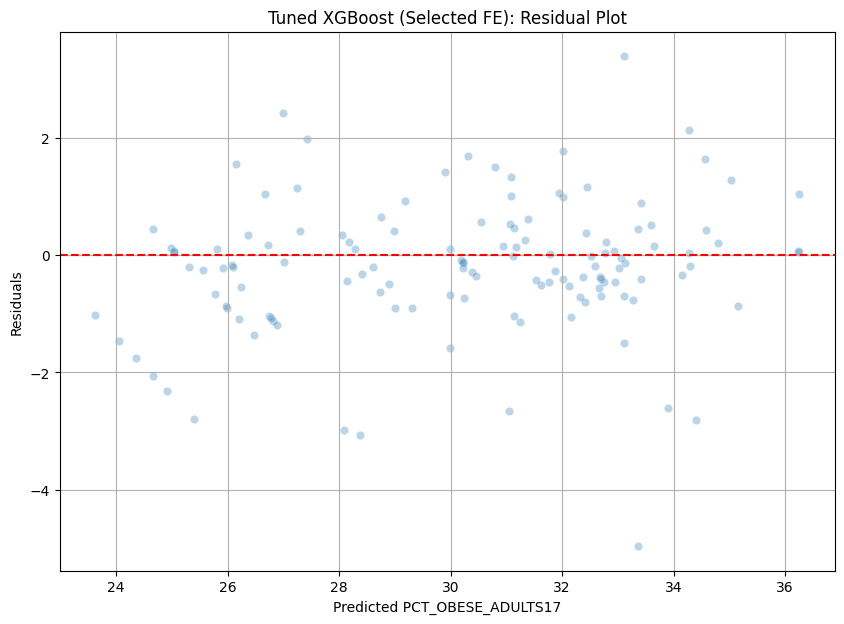

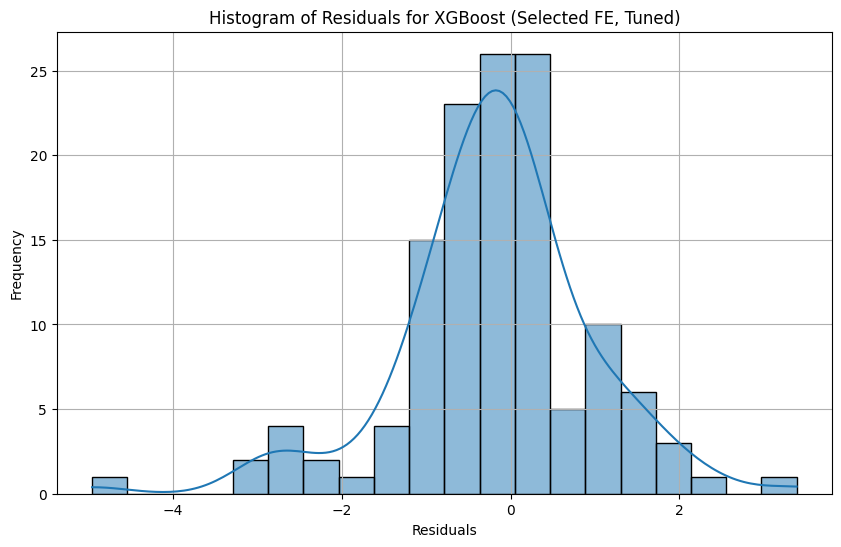

In [25]:
# Plotting actual vs. predicted values for the Tuned XGBoost Model
plt.figure(figsize=(10, 7))
sns.regplot(x=y_test, y=y_pred_best_xgb, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Actual PCT_OBESE_ADULTS17')
plt.ylabel('Predicted PCT_OBESE_ADULTS17')
plt.title('Tuned XGBoost (Selected FE): Actual vs. Predicted Obesity Rates')
plt.grid(True)
plt.show()

# Calculate residuals
residuals_xgb = y_test - y_pred_best_xgb

# Plotting residuals vs. predicted values
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred_best_xgb, y=residuals_xgb, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted PCT_OBESE_ADULTS17')
plt.ylabel('Residuals')
plt.title('Tuned XGBoost (Selected FE): Residual Plot')
plt.grid(True)
plt.show()

# Plotting histogram of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals_xgb, kde=True)
plt.title('Histogram of Residuals for XGBoost (Selected FE, Tuned)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [26]:
y_pred_best_xgb_train = best_xgb_model.predict(X_train)


### Overfitting Check: Actual vs. Predicted Plots (Train vs. Test)

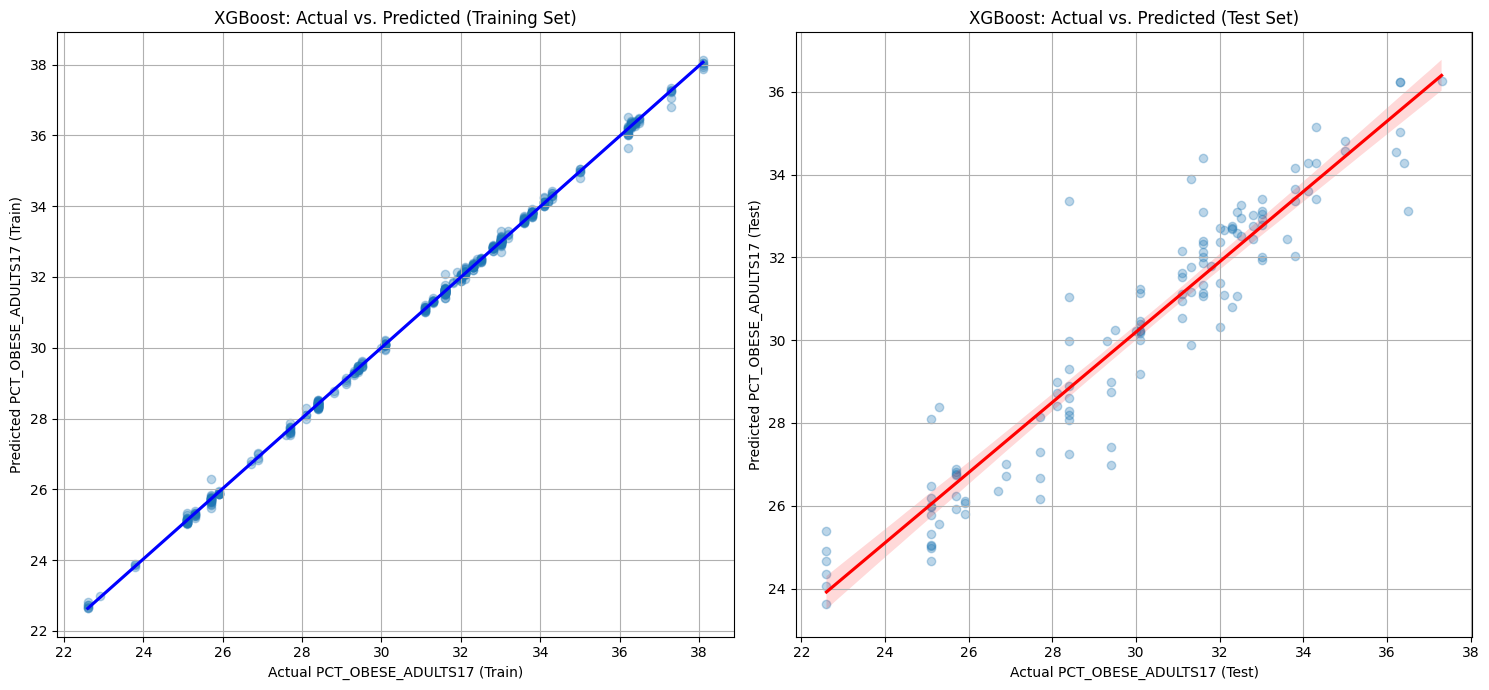

In [27]:
plt.figure(figsize=(15, 7))

# Plotting actual vs. predicted values for the Training Set
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.regplot(x=y_train, y=y_pred_best_xgb_train, scatter_kws={'alpha':0.3}, line_kws={'color':'blue'})
plt.xlabel('Actual PCT_OBESE_ADULTS17 (Train)')
plt.ylabel('Predicted PCT_OBESE_ADULTS17 (Train)')
plt.title('XGBoost: Actual vs. Predicted (Training Set)')
plt.grid(True)

# Plotting actual vs. predicted values for the Test Set
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.regplot(x=y_test, y=y_pred_best_xgb, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Actual PCT_OBESE_ADULTS17 (Test)')
plt.ylabel('Predicted PCT_OBESE_ADULTS17 (Test)')
plt.title('XGBoost: Actual vs. Predicted (Test Set)')
plt.grid(True)

plt.tight_layout()
plt.show()

### Overfitting Check: Residual Plots (Train vs. Test)

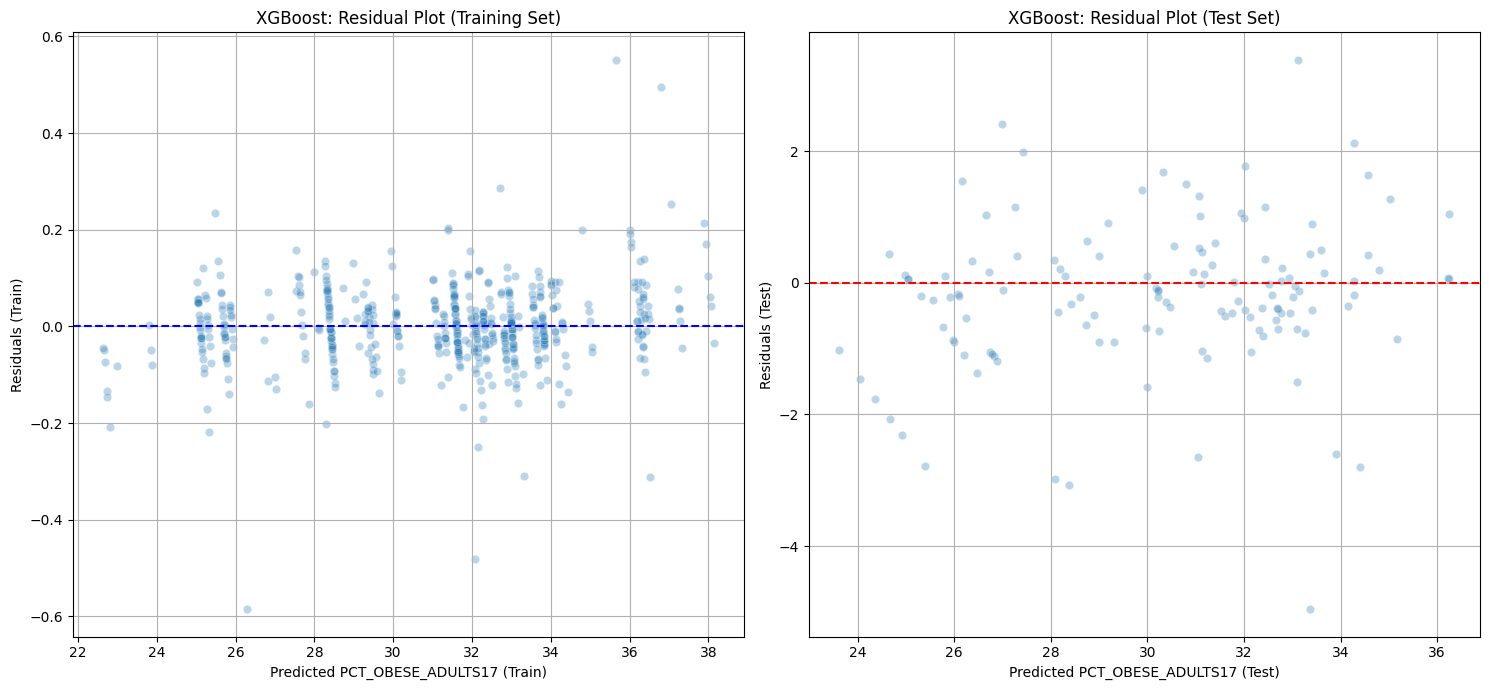

In [28]:
residuals_train = y_train - y_pred_best_xgb_train
residuals_test = y_test - y_pred_best_xgb

plt.figure(figsize=(15, 7))

# Plotting residuals vs. predicted values for the Training Set
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.scatterplot(x=y_pred_best_xgb_train, y=residuals_train, alpha=0.3)
plt.axhline(y=0, color='blue', linestyle='--')
plt.xlabel('Predicted PCT_OBESE_ADULTS17 (Train)')
plt.ylabel('Residuals (Train)')
plt.title('XGBoost: Residual Plot (Training Set)')
plt.grid(True)

# Plotting residuals vs. predicted values for the Test Set
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.scatterplot(x=y_pred_best_xgb, y=residuals_test, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted PCT_OBESE_ADULTS17 (Test)')
plt.ylabel('Residuals (Test)')
plt.title('XGBoost: Residual Plot (Test Set)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [29]:
metrics_df_final = pd.DataFrame(model_metrics_final).T

print("--- Best Model Performance ---")
display(metrics_df_final.round(2))

--- Best Model Performance ---


,MSE,RMSE,MAE,R2
"XGBoost (Tuned, Selected FE)",1.34,1.16,0.81,0.89
